# 🐄 Contagem de Rebanho por Drone — Treino no Google Colab

Notebook pronto para treinar o detector de gado usando a GPU gratuita do Colab.

**Antes de começar — ative a GPU:**

Menu **Ambiente de execução → Alterar o tipo de ambiente de execução → Acelerador de hardware: GPU (T4) → Salvar**

Depois é só rodar as células **de cima para baixo** (clique no ▶ de cada uma, ou Shift+Enter).

## 1. Verificar a GPU

Se aparecer o nome de uma placa (ex.: Tesla T4), está tudo certo. Se der erro, volte e ative a GPU no menu acima.

In [ ]:
!nvidia-smi

## 2. Instalar as bibliotecas

Instala o Ultralytics (YOLO) e o SAHI. Leva ~1 minuto.

In [2]:
!pip install -q ultralytics sahi

import torch
from ultralytics import YOLO
print('GPU disponivel:', torch.cuda.is_available())

GPU disponivel: True


## 3. Trazer o dataset

Escolha **UMA** das opções abaixo. A mais fácil é a **A (Roboflow)**.

---
### Opção A — Roboflow (recomendada)

1. Em https://universe.roboflow.com busque `cattle aerial` ou `cow counting`.
2. Escolha um dataset (confira a licença), clique em **Download Dataset → formato YOLOv8**.
3. Selecione **"show download code"** e copie o trecho `pip install roboflow ...`.
4. Cole o código copiado na célula abaixo, no lugar do exemplo, e rode.

In [1]:
# COLE AQUI o código que o Roboflow te deu. Exemplo do formato:

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="rEFFjVCnIK3ahMSLvwhy")
project = rf.workspace("arthurmessias").project("cattle-bmfuz")
version = project.version(2)
dataset = version.download("yolov8")
print("Dataset baixado para:", dataset.location)

# List contents of the dataset location
!ls -F {dataset.location}

#
# Depois de baixar, o caminho do data.yaml costuma ser algo como:
# /"C:\Users\paulo\Downloads\cattle.v2i.yolov8\data.yaml"

loading Roboflow workspace...
loading Roboflow project...
Dataset baixado para: /content/cattle-2
data.yaml  README.dataset.txt  README.roboflow.txt  test/  train/  valid/


---
### Opção B — Subir seu próprio ZIP

Se você tem suas imagens já anotadas no formato YOLO, compacte tudo num `dataset.zip` (com pastas `images/` e `labels/`, ou `train/valid/`), rode a célula abaixo e selecione o arquivo. Depois descompacte.

In [3]:
# from google.colab import files
# up = files.upload()          # selecione seu dataset.zip
# !unzip -q dataset.zip -d /content/dataset
# !ls /content/dataset

## 4. Conferir o caminho do `data.yaml`

Ajuste a variável abaixo para o caminho do `data.yaml` do seu dataset e rode. A célula mostra o conteúdo para você conferir os nomes das pastas (train/val/test) e a classe.

In [4]:
# Acha o data.yaml automaticamente (nao precisa saber o caminho exato)
import glob, os

encontrados = glob.glob('/content/**/data.yaml', recursive=True)

if not encontrados:
    print('❌ Nenhum data.yaml encontrado em /content.')
    print('   Rode de novo a celula do Roboflow (celula 6) e confira se baixou.')
    print('\nPastas dentro de /content:')
    !ls -F /content
else:
    DATA_YAML = encontrados[0]
    print(f'✅ data.yaml encontrado em: {DATA_YAML}\n')
    print(open(DATA_YAML).read())

✅ data.yaml encontrado em: /content/cattle-2/data.yaml

names:
- cow
nc: 1
roboflow:
  license: CC BY 4.0
  project: cattle-bmfuz
  url: https://universe.roboflow.com/arthurmessias/cattle-bmfuz/dataset/2
  version: 2
  workspace: arthurmessias
test: ../test/images
train: ../train/images
val: ../valid/images



## 5. Treinar 🚀

Primeiro treino com o modelo leve `yolov8n` e 50 épocas — rápido, para ver funcionando. Depois você pode trocar para `yolov8m.pt` e aumentar as épocas para ganhar precisão.

> Se der erro de memória (GPU), reduza `batch` para 8 ou `imgsz` para 640.

In [5]:
# importa aqui tambem, para funcionar mesmo que a sessao tenha reiniciado
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=1024,
    batch=16,
    name='contagem_gado',
    degrees=180, flipud=0.5, fliplr=0.5, mosaic=1.0,
    patience=25,
)
print('\nTreino concluido! Pesos em: runs/detect/contagem_gado/weights/best.pt')

Ultralytics 8.4.109 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cattle-2/data.yaml, degrees=180, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=contagem_gado, nbs=64, nms=False,

## 6. Ver os resultados do treino

Mostra os gráficos de perda e métricas gerados automaticamente.

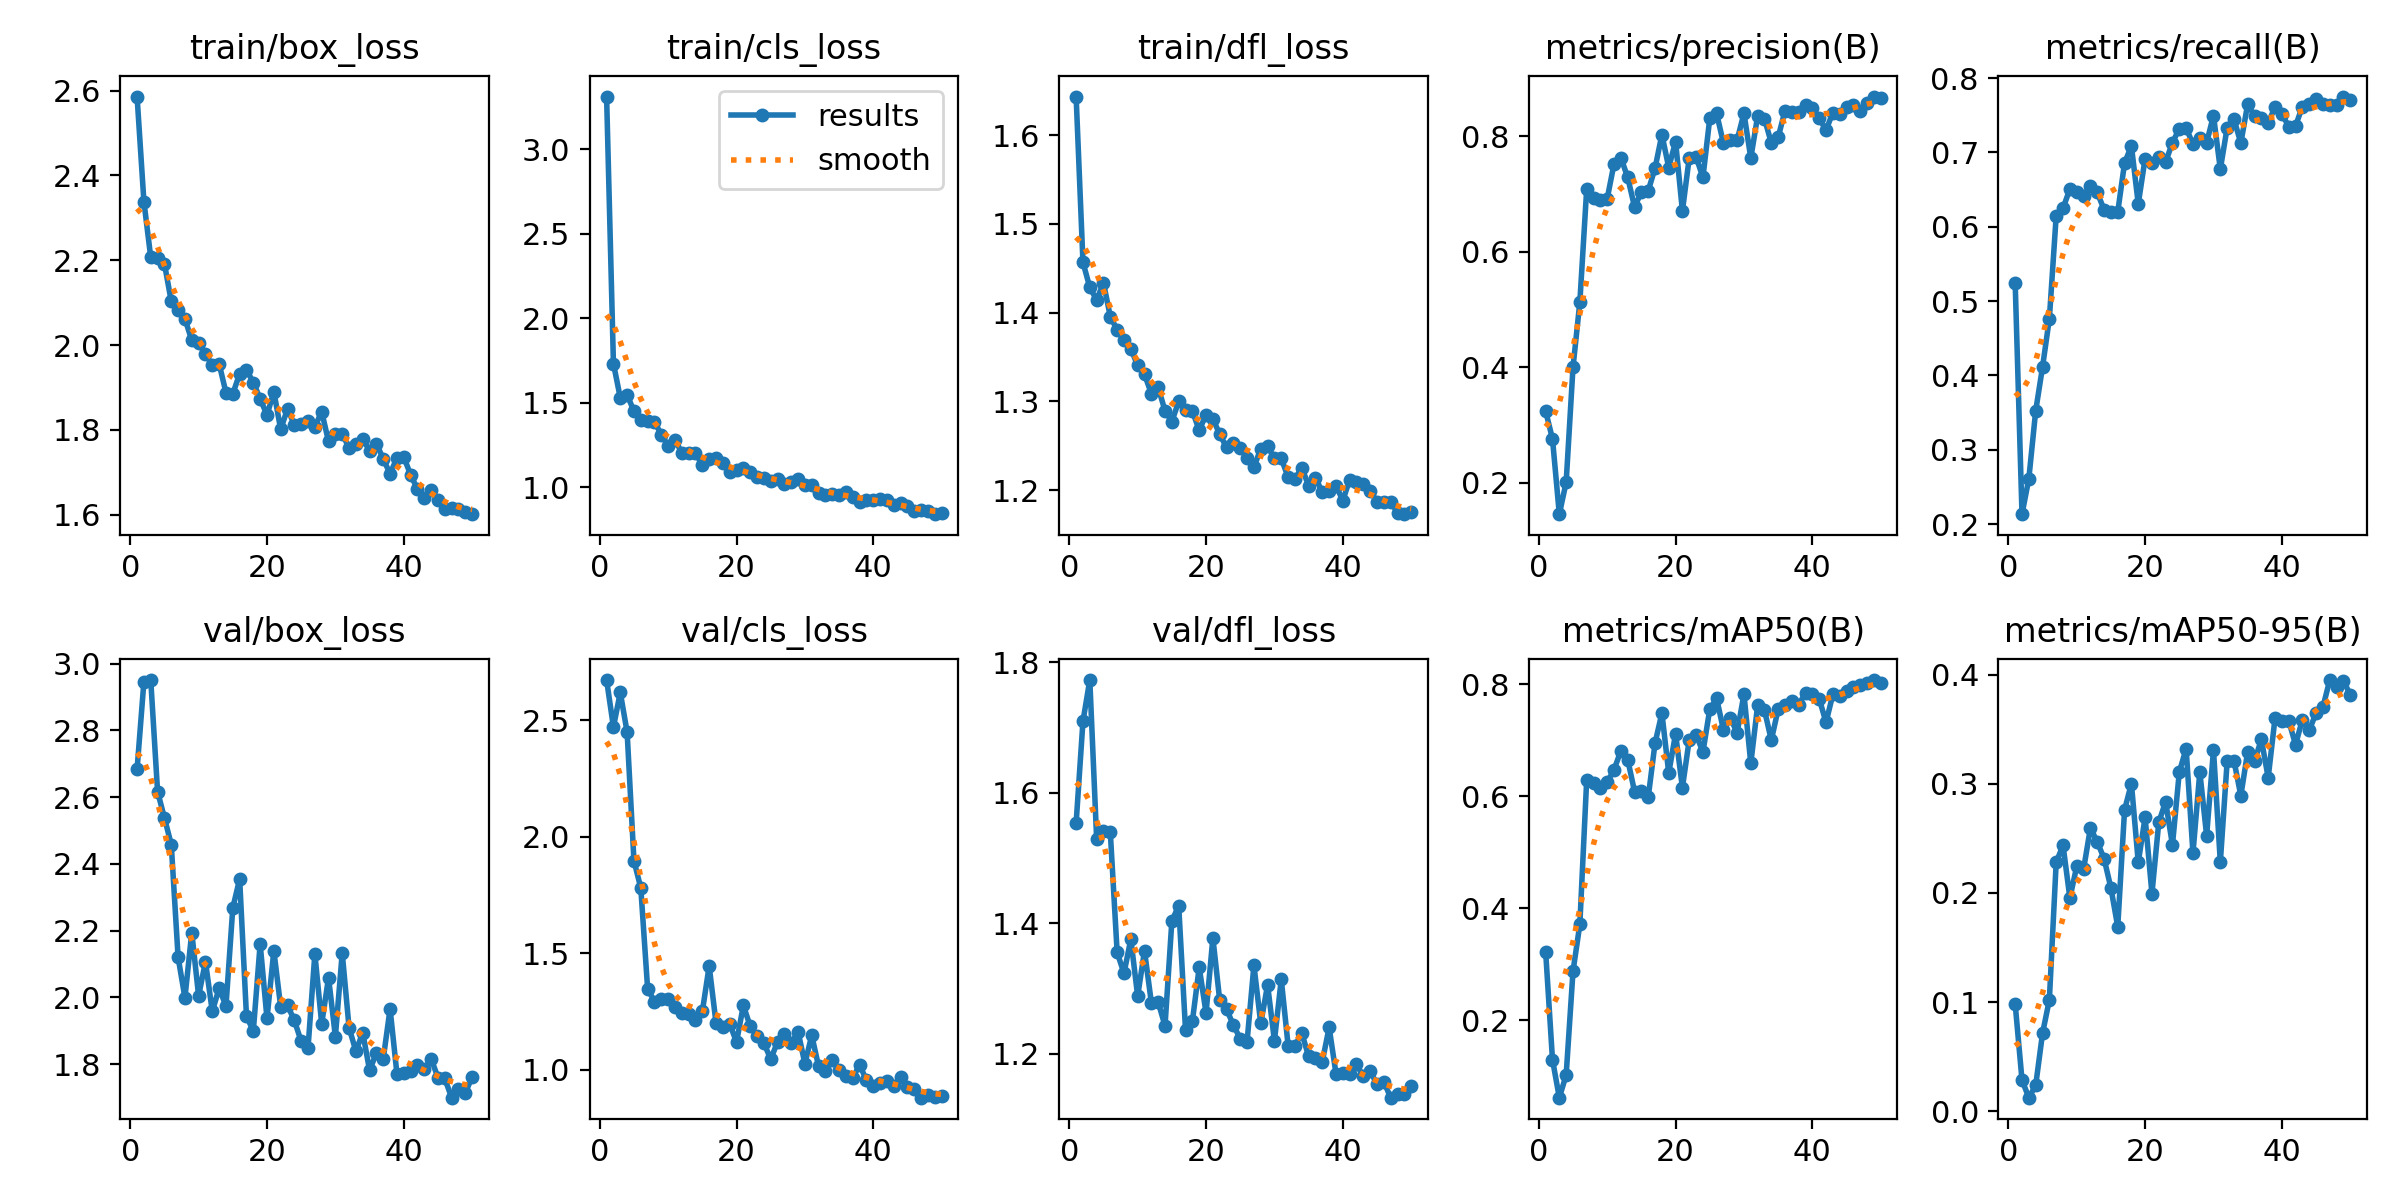

In [6]:
from IPython.display import Image, display
display(Image('runs/detect/contagem_gado/results.png'))

## 7. Testar a contagem numa imagem (com SAHI)

Faz o fatiamento (tiling) e conta os animais numa imagem aérea. Suba uma imagem de teste e ajuste o caminho.

Saving 8da0a903-6107-4ec3-affa-4f03129a36db_jpg.rf.b5c8378495667fb7471c8a67d3b7f1f8.jpg to 8da0a903-6107-4ec3-affa-4f03129a36db_jpg.rf.b5c8378495667fb7471c8a67d3b7f1f8.jpg
Performing prediction on 1 slices.

🐄 Animais detectados: 19


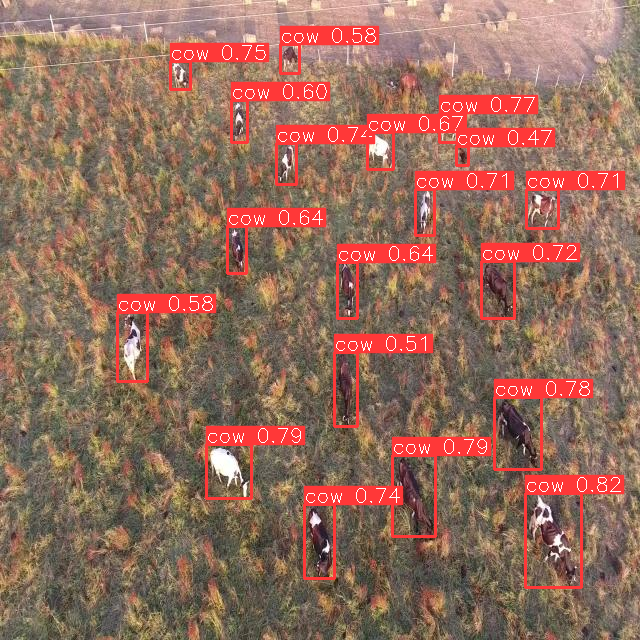

In [12]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from IPython.display import Image, display

# UPLOAD your test image here. For example, uncomment the lines below, run the cell,
# and select your image file from your local computer:
from google.colab import files
uploaded = files.upload()
IMG_TESTE = list(uploaded.keys())[0]

# IMG_TESTE = "/content/pasto.jpg"   # <-- suba uma imagem e ajuste o caminho

det = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path='runs/detect/contagem_gado/weights/best.pt',
    confidence_threshold=0.3,
    device='cuda:0',
)

res = get_sliced_prediction(
    image=IMG_TESTE, detection_model=det,
    slice_height=1024, slice_width=1024,
    overlap_height_ratio=0.2, overlap_width_ratio=0.2,
    postprocess_type='NMS',
)

print(f'\n🐄 Animais detectados: {len(res.object_prediction_list)}')
res.export_visuals(export_dir='/content/', file_name='resultado')
display(Image('/content/resultado.png'))

## 8. Baixar o modelo treinado

O `best.pt` é o seu modelo. Baixe para guardar (⚠️ o Colab apaga tudo quando a sessão fecha).

In [13]:
from google.colab import files
files.download('runs/detect/contagem_gado/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>